# Melbourne Suburb Analytics

## Section 2: Analysis

## 2.1 Setup

### 2.1.1 Configure Libraries

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm

In [2]:
pd.set_option('display.max_columns', None)

---

### 2.1.2 Load Dataset

In [3]:
proj_root = Path.cwd().parent
df_raw = pd.read_csv(proj_root/"data"/"processed"/"melb_data_cleaned.csv")

df = df_raw.copy()

<sub>◦ *This notebook uses exported csv from [01_cleaning.ipynb](./01_cleaning.ipynb), not in-memory state*</sub>

---

## 2.2 Analysis

### 2.2.1 Does average price differ significantly between two property types?

The two property types we will be comparing are **houses** `h` and **units** `u`

Meaning: do houses actually sell for more compared to units, or is this information just luck of the chosen properties from this dataset?

---

#### Hypothesis
Null Hypothesis ($H_0$): The average prices are the same, where any observed difference in the sample is due to random sampling (chance)  
- $H_0$: $μ_h = μ_u$  

Alternative Hypothesis ($H_1$): The average prices are the different, where there is a genuine difference between the **population** mean house price and the **population** mean unit price
- $H_1$: $μ_h \neq μ_u$

---

#### Descriptive Statistics
We identify the sample mean (x̄), standard deviation (s), sample size (n) for houses and units, and calculate the mean ratio.

In [4]:
summary = df.groupby("Type")["Price"].agg(["mean", "std", "count"])

summary.style.format("{:.2f}") ## .2f for display

,mean,std,count
Type,,,
h,1242664.76,668078.74,9449.00
t,933735.05,395038.25,1114.00
u,605127.48,260987.45,3017.00


In [5]:
summary.loc["h", "mean"]/summary.loc["u", "mean"]

np.float64(2.0535586182904413)

For houses and units (Price):  
`h` :  
sample mean (x̄) = 1242664.76  
standard deviation (s) = 668078.74  
sample size (n) = 9449  

`u` :  
sample mean (x̄) = 605127.48	  
standard deviation (s) = 260987.45  
sample size (n) = 3017 

- Houses sell for roughly **2.05x** the price of units on average

<sub>**rounded to 2dp* </sub>  

---

#### Visualisation
Before testing if the difference is statistically significant, we will plot the shape of each group's price distribution

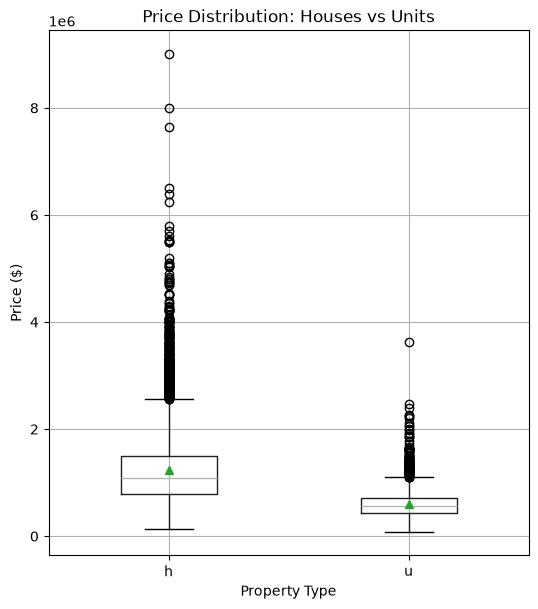

In [6]:
fig, ax = plt.subplots(figsize=(6, 7))
df.loc[df["Type"].isin(["h", "u"])].boxplot(
    column = "Price",
    by = "Type",
    ax = ax,
    widths = .4,
    showmeans = True,
)
ax.set_title('Price Distribution: Houses vs Units')
ax.set_xlabel('Property Type')
ax.set_ylabel('Price ($)')
plt.suptitle('')
plt.show()

- Houses `h` have both a taller box (larger IQR) and a much longer tail of outlier points (up to ~$9M) compared to units `u` (up to ~$3.6M)
    - This correlates to the standard deviations found above, where houses' larger and more frequent outliers leads to a larger standard deviation.
    - The difference in box height (middle 50%) also impacts its std.
- The green triangle on the boxplot (mean) sits visibly above the median line (line in the center of the box) for both groups, where it is more noticeable for houses
    - Shows a right-skew pattern where a small number of expensive properties (outliers) pull the mean up without moving the median
    - There is a clear seperation between the sample means of houses and units where houses clearly have a higher mean price

---

#### Standard Error
We find the **standard error** of the difference between two means using:
$$
SE = \sqrt{\frac{s_h^2}{n_h} + \frac{s_u^2}{n_u}}
$$
- SE shrinks when: sample size is large or there is less noise
- SE grows when: sample size is small or data is spread out

In [7]:
s_h = summary["std"]["h"]
n_h = summary["count"]["h"]
s_u = summary["std"]["u"]
n_u = summary["count"]["u"]
se = np.sqrt((s_h**2/n_h)+(s_u**2/n_u))
print(se)

8355.386492517506


Standard Error (SE) of the difference in mean prices between groups `h` and `u` = **~8355.38**

---

#### t-statistic
We now compute the **t-statistic** to compare our calculated SE using:
$$
t = \frac{\bar{x}_h - \bar{x}_u}{SE}
$$
- This shows (the observed difference in means) ÷ (difference between two sample means expected from random sampling)
- A larger (absolute) t-statistic = the observed difference is **unlikely to be explained just by random sampling**
    - observed difference is **most likely to continue** if the sampling process were to be repeated
    - observed difference is **many standard errors away from 0**
- A t-statistic close to 0 = the observed difference could **possibly be explained by random sampling**
    - observed difference may be **less stable** and could change from sample to sample by chance
    - observed difference is **a few standard errors away from 0**

In [8]:
difference = summary["mean"]["h"]-summary["mean"]["u"]
difference

np.float64(637537.2765514065)

In [9]:
t_stat = difference/se
print(t_stat)

76.30254771844963


t-statistic = ~76.3
- The t-statistic is very large in magnitude, indicating that the observed difference in mean prices between houses and units is extremely large, relative to the estimated sampling uncertainty
- This shows that the difference in mean prices are highly stable and are likely to remain meaningful if the sampling process were repeated

---

#### Degrees of freedom
We must calculate the degrees of freedom (df) in order to find the p-value.
- df determines which t-distribution to be used when interpreting the t-statistic
- Conceptually, df represents the amount of information avaliable for estimating uncertainty from the sample data
    - more information = reduces uncertainty in the estimated sampling distribution
    - larger sample sizes provide more information about the populations
- As df increases, the t-distribution becomes more similar to the standard **normal** distribution

Since the house and unit groups have **different sample sizes and variances**, the Welch-Satterthwaite approximation is used to estimate df:
$$
df
=
\frac{
\left(
\frac{s_h^2}{n_h}
+
\frac{s_u^2}{n_u}
\right)^2
}
{
\frac{
\left(\frac{s_h^2}{n_h}\right)^2
}{n_h-1}
+
\frac{
\left(\frac{s_u^2}{n_u}\right)^2
}{n_u-1}
}
$$

In [10]:
div_h = s_h**2/n_h
div_u = s_u**2/n_u
top = (div_h+div_u)**2
bottom_left = ((div_h)**2)/(n_h-1)
bottom_right = ((div_u)**2)/(n_u-1)
d_f = top/(bottom_left+bottom_right)
print(d_f)

12029.283596165345


Degrees of freedom = ~12029
- This means we have a very large amount of information avaliable for estimating the sampling distribution
    - Hence, the corresponding t-distrubtion is **extremely close** to the standard distribution
    - This means small uncertainty with estimating the sampling distribution

---

#### p-value
We now convert this into a **p-value** via the t-statistic.
- p-value represents the probability of observing a t-statistic at least as extreme as the one obtained, assuming the null hypothesis ($H_0$) is true
- df determines the appropiate t-distrubtion used in this calculation

- A smaller p-value = the observed difference would be **unlikely** if the population mean prices were actually equal
- A large p-value = the observed difference is **reasonably consistent** with random sampling variation if the population mean prices were equal

For a **two-tailed Welch t-test**, the p-value is:
$$
p = 2 \times P(T \ge |t|)
$$

where:

- $T$ utilizes a t-distribution with the calculated degrees of freedom.
- $|t|$ is the absolute value of the calculated t-statistic.
- We multiply by 2 to account for both tails of the distribution, since we are testing for **any difference** in mean price rather than a specific direction.

In [11]:
p_val = 2 * stats.t.sf(abs(t_stat), d_f)
p_val

np.float64(0.0)

p-value = ~0 (so close to 0 that it was reported by Python as `0.0`)

Since the p-value is substantially smaller than the significant level of 0.05, we reject the null hypothesis.  
There is very strong statistical evidence that the average price differs between houses and units.

---

#### Verification with SciPy

In [12]:
house_prices = df.loc[df["Type"] == "h", "Price"]
unit_prices = df.loc[df["Type"] == "u", "Price"]

result = stats.ttest_ind(
    house_prices,
    unit_prices,
    equal_var=False
)
print(f"t-statistic = {result.statistic}, p-value = {result.pvalue}, degrees of freedom = {result.df}")

t-statistic = 76.30254771844955, p-value = 0.0, degrees of freedom = 12029.283596165349


To verify the manual calculations, I used SciPy's `stats.ttest_ind()` function to perform Welch's two-sample t-test.

The test returned:
- t-statistic = ~76.3
- degrees of freedom = ~12029
- pvalue = ~0

These value match the manually calculated t-statistic, degrees of freedom and p-value which confirms that the calculations performed above are correct.

---

#### Conclusion

The extremely large t-statistic (76.3) shows that the observed difference in mean prices between houses and units is very large relative to the estimated sampling uncertainty.

The p-value was virtually 0, meaning that the observed difference would be very unlikely if the population mean house price and population mean unit price were equal.

Therefore, we **reject** the null hypothesis ($H_0$).
There is **very strong statistical evidence** that **the average property price differs between houses and units**.  

---

### 2.2.2 How do price and its likely predictors relate to each other?

Columns in scope: `Price`, `Distance`, `Rooms`, `Bathroom`, `Landsize`, `BuildingArea`  
- where `Landsize` is split into units `u` and (houses `h` with townhalls `t`), b/c of different interpretations of 'zero' (see 01_cleaning notebook 'Outliers')
- `Car` was not chosen since it is a less significant factor than others
- `YearBuilt` was not chosen since it is missing a significant amount of data (identified in 01_cleaning notebook)

Meaning: I will be comparing
- Price vs predictors, of how different factors effect price
- Predictors vs predictors, to identify any strong correlations between the explanatory variables. High correlation between predictors can cause multicollinearity where it makes it difficult to establish their individual effects on price and may cause unstable coefficient estimates in regression.

---

#### Covariance
We find the sample covariance for two variables X and Y:
$$
\operatorname{Cov}(X,Y)
=
\frac{1}{n-1}
\sum_{i=1}^{n}
(x_i-\bar{x})(y_i-\bar{y})
$$
- Where X represents Price and Y represents factors
- For each data point, we multiply how far X and Y are from their means.
    - Each row's results is averaged, resulting in if the two variables move in same or opposite directions from their means
- Cov(X,Y) > 0 = positive relationship
- Cov(X,Y) < 0 = negative relationship
- Cov(X,Y) = near 0 = no consistent pattern (no linear relationship)


In [13]:
## factors
price = df["Price"]
distance = df["Distance"]
rooms = df["Rooms"]
bathrooms = df["Bathroom"]
landsize_u = df.loc[df["Type"] == "u", "Landsize"]
landsize_h_t = df.loc[df["Type"].isin(["h", "t"]), "Landsize"].dropna() ## contains NaN
building_area = df["BuildingArea"].dropna() ## contains NaN

## price columns for u, h+t, building area (doesn't use all price rows)
price_l_u = df.loc[landsize_u.index, "Price"]
price_l_h_t = df.loc[landsize_h_t.index, "Price"]
price_b_a = df.loc[building_area.index, "Price"]

## performs covariance equation
cov_p_d = (((price-price.mean())*(distance-distance.mean())).sum())/(len(distance)-1)
cov_p_r = (((price-price.mean())*(rooms-rooms.mean())).sum())/(len(rooms)-1)
cov_p_b = (((price-price.mean())*(bathrooms-bathrooms.mean())).sum())/(len(bathrooms)-1)
cov_p_l_u = (((price_l_u-price_l_u.mean())*(landsize_u-landsize_u.mean())).sum())/(len(landsize_u)-1)
cov_p_l_h_t = (((price_l_h_t-price_l_h_t.mean())*(landsize_h_t-landsize_h_t.mean())).sum())/(len(landsize_h_t)-1)
cov_p_b_a = (((price_b_a-price_b_a.mean())*(building_area-building_area.mean())).sum())/(len(building_area)-1)
print("Covariance between price and:")
print(f"distance = {cov_p_d}")
print(f"rooms = {cov_p_r}")
print(f"bathrooms = {cov_p_b}")
print(f"building area = {cov_p_b_a}")
print(f"landsize (units) = {cov_p_l_u}")
print(f"landsize (houses and townhouses) = {cov_p_l_h_t}")


Covariance between price and:
distance = -609771.9883614741
rooms = 303453.0625157359
bathrooms = 206533.02846699962
building area = 30964763.041160982
landsize (units) = 23518157.446157563
landsize (houses and townhouses) = 35776317.1676481


We use `.cov()` to verify:

In [ ]:
cov_matrix_1 = df[["Price", "Distance", "Rooms", "Bathroom", "BuildingArea"]].cov()
cov_matrix_u = df.loc[df["Type"] == "u", ["Price", "Landsize"]].cov()
cov_matrix_h_t = df.loc[df["Type"].isin(["h", "t"]), ["Price", "Landsize"]].cov()
print(cov_matrix_1.loc["Price"].drop("Price"))
print(f"units: {cov_matrix_u.loc['Price'].drop('Price')}")
print(f"houses and townhouses: {cov_matrix_h_t.loc['Price'].drop('Price')}")

Distance       -6.097720e+05
Rooms           3.034531e+05
Bathroom        2.065330e+05
BuildingArea    3.096476e+07
Name: Price, dtype: float64
units: Landsize    2.351816e+07
Name: Price, dtype: float64
houses and townhouses: Landsize    3.577632e+07
Name: Price, dtype: float64


The results show that price and:
- `Distance` have a negative covariance > properties located further from the CBD tend to have lower prices
- `Rooms` have a positive covariance > properties with more rooms generally have higher prices
- `Bathrooms` have a positive covariance > properties with more bathrooms generally are more expensive
- `Landsize` for both units and houses/townhouses have a positive covariance > larger properties tend to have higher prices
- `BuildingArea` have a positive covariance > large building areas are associated with higher prices

---

#### Correlation
We calculate Pearson's correlation coefficient:
$$
r_{X,Y}
=
\frac{\operatorname{Cov}(X,Y)}
{\sigma_X \sigma_Y}
$$
- The calculated covariance values depend entirely on the units and scale of the variables. 
    - Therefore to determine its magnitude, we will standardise these numbers by dividing by the product of the standard deviations of the two variables
- Unlike covariance, correlation is unitless and lies between -1 and 1

- The sign of the correlation coefficient indicates the direction of the relationship while its magnitude indicates its strength
    - $r = 1$ indicates a perfect positive linear relationship.
    - $r = -1$ indicates a perfect negative linear relationship.
    - $r = 0$ indicates no linear relationship.


In [15]:
## finds standard deviation of factors
std_price = price.std()
std_distance = distance.std()
std_rooms = rooms.std()
std_bathrooms = bathrooms.std()
std_building_area = building_area.std()
std_landsize_u = landsize_u.std()
std_landsize_h_t = landsize_h_t.std()

## price standard deviation for u, h+t, building area (doesn't use all price rows)
std_b_a = price_b_a.std()
std_l_u = price_l_u.std()
std_l_h_t = price_l_h_t.std()

## performs correlation calculation
r_p_d = cov_p_d/(std_price*std_distance)
r_p_r = cov_p_r/(std_price*std_rooms)
r_p_b = cov_p_b/(std_price*std_bathrooms)
r_p_b_a = cov_p_b_a/(std_b_a*std_building_area)
r_p_l_u = cov_p_l_u/(std_l_u*std_landsize_u)
r_p_l_h_t = cov_p_l_h_t/(std_l_h_t*std_landsize_h_t)
print("Correlation between price and:")
print(f"distance = {r_p_d}")
print(f"rooms = {r_p_r}")
print(f"bathrooms = {r_p_b}")
print(f"building area = {r_p_b_a}")
print(f"landsize (units) = {r_p_l_u}")
print(f"landsize (houses and townhouses) = {r_p_l_h_t}")

Correlation between price and:
distance = -0.16252183786382543
rooms = 0.49663367618653
bathrooms = 0.4670381828201493
building area = 0.5306806271914454
landsize (units) = 0.05213297069488481
landsize (houses and townhouses) = 0.04880210446052436


We use `.corr()` to verify:

In [ ]:
cor_matrix_1 = df[["Price", "Distance", "Rooms", "Bathroom", "BuildingArea"]].corr()
cor_matrix_u = df.loc[df["Type"] == "u", ["Price", "Landsize"]].corr()
cor_matrix_h_t = df.loc[df["Type"].isin(["h", "t"]), ["Price", "Landsize"]].corr()
print(cor_matrix_1.loc["Price"].drop("Price"))
print(f"units: {cor_matrix_u.loc['Price'].drop('Price')}")
print(f"houses and townhouses: {cor_matrix_h_t.loc['Price'].drop('Price')}")

Distance       -0.162522
Rooms           0.496634
Bathroom        0.467038
BuildingArea    0.530681
Name: Price, dtype: float64
units: Landsize    0.052133
Name: Price, dtype: float64
houses and townhouses: Landsize    0.048802
Name: Price, dtype: float64


From the results, the strongest positive correlations with `Price` were:
- `BuildingArea` ($r \approx 0.531$)
- `Rooms` ($r \approx 0.497$)
- `Bathrooms` ($r \approx 0.467$)

This suggests that larger properties, properties with more romms and properties with more bathrooms tend to have higher prices. Among the variables examined, `BuildingArea` seems to have the strongest linear relationship with Price.

`Distance` had  a weak negative correlation with Price ($r \approx -0.163$) which shows that the relationship of a property located further from the CBD being less expensive does exist but is relatively weak.

`Landsize` showed the weakest positive correlations (<0.1) with Price for both units ($r \approx 0.052$) and houses/townhouses ($r \approx 0.049$), meaning that land size has little to no linear relationship with price.
- Because of the weak relationship with `Price`, `Landsize` will not be used for subsequent regression analyses.

---

#### Predictor Correlations
We calculate correlations between predictors (rather than to price) to detect potential multicollinearity.  
- Multicollinearity is where multiple variables contain similar information
    - This is not ideal in a regression model since it will be difficult to isolate each predictor's individual effect on the response variable (Y or `Price`) which could lead to unstable coefficient estimates and inflated standard errors.
- We will use a correlation matrix between the variables `Distance`, `Rooms`, `Bathrooms` and `BuildingArea`, where we will take note of strong correlations.
    - We will not be using `Landsize` because of the decision of not using `Landsize` in future questions

In [23]:
cor_predictor_matrix = df.loc[:, ["Distance", "Rooms", "Bathroom", "BuildingArea"]].corr()
cor_predictor_matrix

,Distance,Rooms,Bathroom,BuildingArea
Distance,1.000000,0.294203,0.127155,0.175621
Rooms,0.294203,1.000000,0.592934,0.614419
Bathroom,0.127155,0.592934,1.000000,0.558099
BuildingArea,0.175621,0.614419,0.558099,1.000000


From the results, the strongest correlations were observed between:
- `Rooms` and `BuildingArea` ($r \approx 0.614$)
- `Rooms` and `Bathroom` ($r \approx 0.593$)
- `Bathroom` and `BuildingArea` ($r \approx 0.558$)

This is expected since larger properties, meaning larger building area, would typically have more rooms and more bathrooms.  

`Distance` had relatively weak correlations to other predictors (<0.3), suggesting that distance provides independent information.

Overall, no correlation exceeded 0.7. While `Rooms`, `Bathroom`, and `BuildingArea` are moderately correlated because of their relation to **property size** , there is no strong evidence of multicollinearity among the predictors selected for later regression analysis.

---

#### Correlation Significance Test
The strongest observed relationship was between `Price` and `BuildingArea`. So to test whether this observed correlation could've arised by random choice, we will perform a pearson correlation test.  

**Hypothesis**  
Null Hypothesis ($H_0$): The true population correlation between `Price` and `BuildingArea` is 0, meaning there is no actual linear relationship between the variables.  
- $H_0$: $\rho = 0$

Alternative Hypothesis ($H_1$): The true population correlation between `Price` and `BuildingArea` is not 0, meaning a linear relationship exists between the variables.
- $H_1$: $\rho \neq 0$  

**t-statistic**  
We first calculate the t-statistic
$$
t
=
r\sqrt{\frac{n-2}{1-r^2}}
$$
where:
- `r` = the **sample** correlation we have derived between X and Y
- `n` = the sample population  

The t-statistic measures how far the observed sample correlation is from the null hypothesis value of $\rho = 0$. Larger absolute t-values indicate stronger evidence against the null hypothesis.

---

#### Conclusion
- Strongest positive relationships with `Price` : `Rooms`, `Bathrooms`, `BuildingArea`
- Weak negative relationship with `Price` : `Distance`
- Very weak relationship with `Price` : `Landsize`
- Moderate relationships between `Rooms`, `Bathrooms`, `BuildingArea`  

Overall, `Rooms`, `Bathroom`, `BuildingArea`, and `Distance` will be used in subsequent regression models, with `Distance` used despite its weaker correlation with Price due to its practical relevance and independent information.
___